In [1]:
import baltic as bt
import pandas as pd
import numpy as np
import json
import os
import matplotlib.pyplot as plt
import itertools
from collections import defaultdict
import statistics
import numpy as np
from scipy.optimize import minimize, LinearConstraint
import warnings
from datetime import datetime
import re
from treetime import TreeTime, TreeTimeError, utils
from dendropy import Tree
from Bio import SeqIO
import random
import math
import scipy.stats as stats

plt.rcParams["font.family"] = "Arial"

In [2]:
clades = ['na_avian', 'eurasian_avian', 'swine']

In [ ]:
json_path = "clock_rate/host_clock_rates.json"

with open(json_path) as f:
    host_stats = json.load(f)

In [4]:
print(host_stats)

{'na_avian': {'clock_rate': 0.0014153628923017929, 'root_yr': 1932.7972743811047}, 'eurasian_avian': {'clock_rate': 0.0010022429427303807, 'root_yr': 1925.5975498054086}, 'swine': {'clock_rate': 0.003923517661115446, 'root_yr': 1965.3744788462288}, 'canine': {'clock_rate': 0.0021760366926091234, 'root_yr': 2004.8254515694057}, 'human': {'clock_rate': 0.00417372439954042, 'root_yr': 1967.4178682706547}, 'equine': {'clock_rate': 0.001865099192944831, 'root_yr': 1954.4550337364963}}


In [ ]:
current_year = 2025
fit_times = [0.5, 2, 6, 10]

results = {clade: {} for clade in clades}

for clade in clades:
    clock_rate = host_stats[clade]["clock_rate"]
    
    for i in range(1000):
        tree = f'hosts/{clade}/trees/randomized_tree_{i}.nwk'
        mytree = bt.loadNewick(tree, absoluteTime=False)
        
        results[clade][i] = {}
        
        mytree.traverse_tree()
        mytree.sortBranches()

        leaf_heights = {leaf.name: (leaf.height, leaf.name.split("|")[1]) for leaf in mytree.getExternal()}
        
        for fit_time in fit_times:

            node_count = node_rea_count = leaf_count = leaf_rea_count = 0
            rea_fit = clonal_fit = rea_unfit = clonal_unfit = 0

            for k in mytree.Objects:
                if k.is_leaf():
                    leaf_count += 1
                    if k.traits.get('is_reassorted'):
                        leaf_rea_count += 1
                elif k.is_node():
                    node_count += 1
                    if k.traits.get('is_reassorted'):
                        node_rea_count += 1

                    # skip nodes that are younger than the fit time 
                    node_age = (current_year - host_stats[clade]['root_yr']) - (k.height / clock_rate)
                    if node_age < fit_time:
                        continue

                    # compute max leaf date under node
                    dates_and_heights = [(leaf_heights[leaf][1], leaf_heights[leaf][0]) for leaf in k.leaves]
                    max_date, leaf_height = max(dates_and_heights, key=lambda x: x[0])

                    date = (leaf_height - k.height) / clock_rate

                    if date > fit_time:
                        if k.traits.get('is_reassorted'):
                            rea_fit += 1
                        else:
                            clonal_fit += 1
                    else:
                        if k.traits.get('is_reassorted'):
                            rea_unfit += 1
                        else:
                            clonal_unfit += 1
            
            results[clade][i][fit_time] = {
                'node_count': node_count,
                'node_rea_count': node_rea_count,
                'leaf_count': leaf_count,
                'leaf_rea_count': leaf_rea_count,
                'rea_fit': rea_fit,
                'clonal_fit': clonal_fit,
                'rea_unfit': rea_unfit,
                'clonal_unfit': clonal_unfit
            }

In [6]:
# with open("fit_counts_per_tree.json", "w") as f:
#     json.dump(results, f, indent=2)

In [7]:
with open("fit_counts_per_tree.json") as f:
    data = json.load(f)

In [8]:
data

{'na_avian': {'0': {'0.5': {'node_count': 1193,
    'node_rea_count': 299,
    'leaf_count': 1194,
    'leaf_rea_count': 327,
    'rea_fit': 165,
    'clonal_fit': 488,
    'rea_unfit': 117,
    'clonal_unfit': 358},
   '2': {'node_count': 1193,
    'node_rea_count': 299,
    'leaf_count': 1194,
    'leaf_rea_count': 327,
    'rea_fit': 127,
    'clonal_fit': 352,
    'rea_unfit': 151,
    'clonal_unfit': 470},
   '6': {'node_count': 1193,
    'node_rea_count': 299,
    'leaf_count': 1194,
    'leaf_rea_count': 327,
    'rea_fit': 75,
    'clonal_fit': 186,
    'rea_unfit': 166,
    'clonal_unfit': 523},
   '10': {'node_count': 1193,
    'node_rea_count': 299,
    'leaf_count': 1194,
    'leaf_rea_count': 327,
    'rea_fit': 58,
    'clonal_fit': 114,
    'rea_unfit': 141,
    'clonal_unfit': 411}},
  '1': {'0.5': {'node_count': 1193,
    'node_rea_count': 304,
    'leaf_count': 1194,
    'leaf_rea_count': 322,
    'rea_fit': 165,
    'clonal_fit': 488,
    'rea_unfit': 121,
    'clona

In [9]:
# in how many of the null datasets do you get a pvalue (or odds ratio) that is at least as extreme 
# or more extreme than the pvalue you get from your real data?

with open("jsons/FET_per_clade.json") as f:
    real_data = json.load(f)
    
real_p = {}

for clade in real_data:
    real_p[clade] = {}
    
    for fit_time in real_data[clade]:
        real_p[clade][fit_time] = real_data[clade][fit_time][3]

In [10]:
real_data

{'na_avian': {'6mo': [1.196953781512605,
   0.9101086124231077,
   1.5742059085265159,
   0.21236906839666453],
  '2yr': [0.9234298050327194,
   0.7021530263317416,
   1.2144398341165676,
   0.5779644187418305],
  '6yr': [0.7373322809786899,
   0.5229258062965005,
   1.0396482369527225,
   0.0924029377290458],
  '10yr': [0.6080142642642643,
   0.39512965480437057,
   0.9355950409033322,
   0.025949664664837238]},
 'eurasian_avian': {'6mo': [0.7008,
   0.41344541285666286,
   1.1878729929705771,
   0.20361979042408923],
  '2yr': [0.6424287067241924,
   0.40574062309724546,
   1.0171883704245246,
   0.07178928426193935],
  '6yr': [0.543859649122807,
   0.33522983432749104,
   0.8823299350350411,
   0.016827076589495844],
  '10yr': [0.5471813725490197,
   0.31102105008071673,
   0.962659776201406,
   0.034975674177774294]},
 'swine': {'6mo': [2.438241899262111,
   1.660718677843477,
   3.5797896649402445,
   1.6416963315216463e-06],
  '2yr': [2.478298548422041,
   1.7697336788541582,
   3

In [11]:
time_map = {
    "0.5": "6mo",
    "2": "2yr",
    "6": "6yr",
    "10": "10yr"
}

alpha = 0.05

significant_counts = {}
total_tests = {}
extreme_counts = {}
tree_ors   = {}   # clade -> fit_time -> list of ORs
tree_pvals = {}   # clade -> fit_time -> list of p-values

for clade in data:

    significant_counts[clade] = {}
    extreme_counts[clade] = {}
    total_tests[clade] = {}
    tree_ors[clade] = {}
    tree_pvals[clade] = {}

    for tree_id in data[clade]:

        for fit_time in data[clade][tree_id]:

            counts = data[clade][tree_id][fit_time]

            a = counts["rea_fit"]
            b = counts["rea_unfit"]
            c = counts["clonal_fit"]
            d = counts["clonal_unfit"]

            significant_counts[clade].setdefault(fit_time, 0)
            extreme_counts[clade].setdefault(fit_time, 0)
            total_tests[clade].setdefault(fit_time, 0)
            tree_ors[clade].setdefault(fit_time, [])
            tree_pvals[clade].setdefault(fit_time, [])

            if (a + b == 0) or (c + d == 0):
                continue

            table = [[a, b], [c, d]]

            odds_ratio, p_value = stats.fisher_exact(table, alternative='two-sided')

            tree_ors[clade][fit_time].append(odds_ratio)
            tree_pvals[clade][fit_time].append(p_value)

            total_tests[clade][fit_time] += 1

            if p_value < alpha:
                significant_counts[clade][fit_time] += 1

            real_time = time_map[fit_time]

            if p_value <= real_p[clade][real_time]:
                extreme_counts[clade][fit_time] += 1

In [12]:
for clade in significant_counts:
    for fit_time in significant_counts[clade]:
        sig = significant_counts[clade][fit_time]
        total = total_tests[clade][fit_time]
        print(f"{clade} | fit_time {fit_time}: {sig}/{total} significant")
    print("\n")

na_avian | fit_time 0.5: 51/1000 significant
na_avian | fit_time 2: 53/1000 significant
na_avian | fit_time 6: 48/1000 significant
na_avian | fit_time 10: 36/1000 significant


eurasian_avian | fit_time 0.5: 41/1000 significant
eurasian_avian | fit_time 2: 47/1000 significant
eurasian_avian | fit_time 6: 45/1000 significant
eurasian_avian | fit_time 10: 39/1000 significant


swine | fit_time 0.5: 55/1000 significant
swine | fit_time 2: 45/1000 significant
swine | fit_time 6: 48/1000 significant
swine | fit_time 10: 36/1000 significant




In [13]:
for clade in extreme_counts:
    for fit_time in extreme_counts[clade]:
        sig = extreme_counts[clade][fit_time]
        total = total_tests[clade][fit_time]
        print(f"{clade} | fit_time {fit_time}: {sig}/{total} as extreme")
    print("\n")

na_avian | fit_time 0.5: 215/1000 as extreme
na_avian | fit_time 2: 549/1000 as extreme
na_avian | fit_time 6: 81/1000 as extreme
na_avian | fit_time 10: 19/1000 as extreme


eurasian_avian | fit_time 0.5: 185/1000 as extreme
eurasian_avian | fit_time 2: 61/1000 as extreme
eurasian_avian | fit_time 6: 18/1000 as extreme
eurasian_avian | fit_time 10: 28/1000 as extreme


swine | fit_time 0.5: 0/1000 as extreme
swine | fit_time 2: 0/1000 as extreme
swine | fit_time 6: 2/1000 as extreme
swine | fit_time 10: 219/1000 as extreme




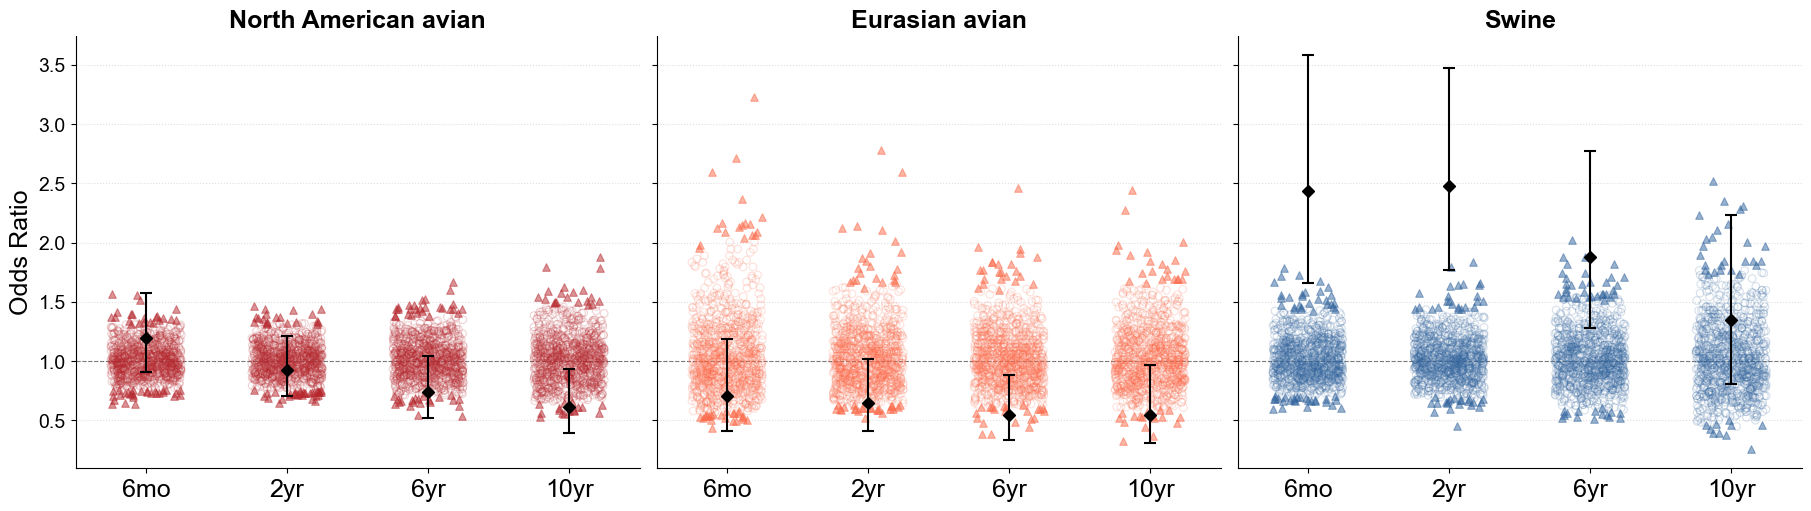

In [14]:

TIME_ORDER = ["0.5", "2", "6", "10"]

periods = ["6mo", "2yr", "6yr", "10yr"]
time_map = dict(zip(TIME_ORDER, periods))

colors = {
    "na_avian":      "#b6282e",
    "eurasian_avian":"#fb6a4a",
    "swine":         "#33659e"
}

clade_names = {
    "na_avian":      "North American avian",
    "eurasian_avian":"Eurasian avian",
    "swine":         "Swine"
}

JITTER_SEED = 42
SIG_ALPHA   = 0.05
rng = np.random.default_rng(JITTER_SEED)

clades   = list(data.keys())
n_clades = len(clades)

fig, axes = plt.subplots(1, n_clades,
                         figsize=(6 * n_clades, 5),
                         constrained_layout=True, sharey=True)
axes = np.array(axes).flatten()

for ax_idx, clade in enumerate(clades):
    ax    = axes[ax_idx]
    color = colors.get(clade, "#888888")

    x_positions = {t: i + 1 for i, t in enumerate(TIME_ORDER)}

    for fit_time in TIME_ORDER:
        x_base = x_positions[fit_time]
        period = time_map[fit_time]

        # real data OR + 95% CI
        or_val, ci_lo, ci_hi, _ = real_data[clade][period]
        ax.errorbar(x_base, or_val,
                    yerr=[[or_val - ci_lo], [ci_hi - or_val]],
                    fmt="D", color="black",
                    markersize=6, linewidth=1.5,
                    capsize=4, capthick=1.5,
                    zorder=6)

        # per-tree scatter
        ors   = np.array(tree_ors[clade].get(fit_time, []))
        pvals = np.array(tree_pvals[clade].get(fit_time, []))

        sig_mask = pvals < SIG_ALPHA
        jitter   = rng.uniform(-0.25, 0.25, size=len(ors))
        xs       = x_base + jitter

        ax.scatter(xs[~sig_mask], ors[~sig_mask],
                   facecolors="none", edgecolors=color,
                   s=30, linewidths=0.8, alpha=0.2, zorder=3)

        ax.scatter(xs[sig_mask], ors[sig_mask],
                   facecolors=color, edgecolors=color,
                   s=30, linewidths=0.8, alpha=0.5, zorder=4, marker="^")

    ax.axhline(1, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xlim(0.5, len(TIME_ORDER) + 0.5)
    ax.set_xticks(list(x_positions.values()))
    ax.set_xticklabels(periods, fontsize=18)
    ax.set_title(clade_names.get(clade, clade), fontsize=18, fontweight="bold")
    ax.grid(axis="y", linestyle=":", alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)

    if ax_idx == 0:
        ax.set_ylabel("Odds Ratio", fontsize=18)
        ax.tick_params(axis="y", labelsize=14)
    else:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)

plt.savefig("OR_per_tree.png", bbox_inches="tight", dpi=150)
plt.show()